<a href="https://colab.research.google.com/github/twahanur/Skin-cancer-Classification-/blob/main/SkinCancerClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Kaggle API setup
!pip install -q kaggle


from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dataset download + unzip (HAM10000)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:29<00:00, 192MB/s]



In [22]:
!pip install -q timm scikit-learn pandas pillow torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
# Metadata load
df = pd.read_csv('ham10000/HAM10000_metadata.csv')


class_map = {
    'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3,
    'mel': 4, 'nv': 5, 'vasc': 6
}
df['label'] = df['dx'].map(class_map)
df['image_path'] = df['image_id'].apply(lambda x: f"ham10000/HAM10000_images_part_1/{x}.jpg"
                                        if os.path.exists(f"ham10000/HAM10000_images_part_1/{x}.jpg")
                                        else f"ham10000/HAM10000_images_part_2/{x}.jpg")


# Train-test split (80-20)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)


beta = 0.999
n_samples = train_df['label'].value_counts().sort_index().values
effective_num = 1.0 - np.power(beta, n_samples)
weights = (1.0 - beta) / effective_num
class_weights = torch.tensor(weights / weights.sum(), dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.1340, 0.0917, 0.0528, 0.3514, 0.0524, 0.0310, 0.2867],
       device='cuda:0')


In [24]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.df.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)
        return image, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = HAMDataset(train_df, transform)
test_dataset = HAMDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [6]:
import tqdm
from tqdm.auto import tqdm

# ConvNeXt-Base + Swin-Base
model_cnn = timm.create_model('convnext_base', pretrained=True, num_classes=7).to(device)
model_swin = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=7).to(device)

def fine_tune_model(model, model_name):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    best_acc = 0.0
    print(f"\n🔥 Starting fine-tuning: {model_name} on {device}")
    print(f"GPU Memory before: {torch.cuda.memory_allocated()/1e9:.2f} GB\n")

    for epoch in range(5):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/5", leave=True)

        for batch_idx, (images, labels) in enumerate(progress_bar):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()


            if batch_idx % 50 == 0:
                progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        print(f"✅ {model_name} Epoch {epoch+1}/5 → Val Accuracy: {acc:.2f}% | Avg Loss: {avg_loss:.4f}")

        scheduler.step(avg_loss)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"💾 Best model saved! (Acc = {best_acc:.2f}%)")

    print(f"\n🎉 {model_name} fine-tuning FINISHED! Best Val Acc: {best_acc:.2f}%\n")


fine_tune_model(model_cnn, "ConvNeXt-Base")
fine_tune_model(model_swin, "Swin-Base")


🔥 Starting fine-tuning: ConvNeXt-Base on cuda
GPU Memory before: 2.15 GB



Epoch 1/5:   0%|          | 0/251 [00:00<?, ?it/s]

✅ ConvNeXt-Base Epoch 1/5 → Val Accuracy: 80.88% | Avg Loss: 1.0473
💾 Best model saved! (Acc = 80.88%)


Epoch 2/5:   0%|          | 0/251 [00:00<?, ?it/s]

✅ ConvNeXt-Base Epoch 2/5 → Val Accuracy: 84.47% | Avg Loss: 0.5648
💾 Best model saved! (Acc = 84.47%)


...

✅ Swin-Base Epoch 3/5 → Val Accuracy: 88.07% | Avg Loss: 0.3741
💾 Best model saved! (Acc = 88.07%)


Epoch 4/5:   0%|          | 0/251 [00:00<?, ?it/s]

✅ Swin-Base Epoch 4/5 → Val Accuracy: 86.67% | Avg Loss: 0.2718


Epoch 5/5:   0%|          | 0/251 [00:00<?, ?it/s]

✅ Swin-Base Epoch 5/5 → Val Accuracy: 87.97% | Avg Loss: 0.1908

🎉 Swin-Base fine-tuning FINISHED! Best Val Acc: 88.07%



### 1. ক্লাস ডিস্ট্রিবিউশন (Class Distribution)

প্রথমে, আমরা `train_df` এবং `test_df` উভয় ডেটাসেটে লেবেলের বন্টন ভিজ্যুয়ালাইজ করব।

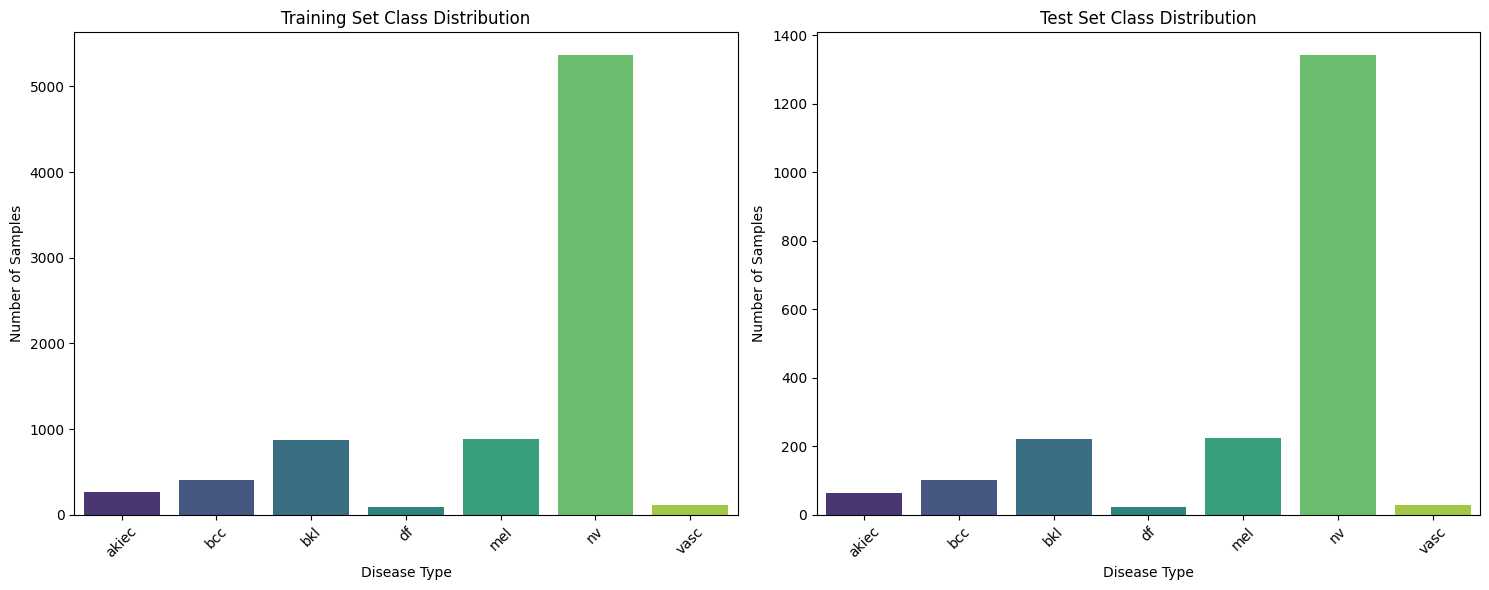

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
class_names = list(class_map.keys())
train_counts = train_df['dx'].value_counts().reindex(class_names, fill_value=0)
test_counts = test_df['dx'].value_counts().reindex(class_names, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training Set Class Distribution
sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Disease Type')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Test Set Class Distribution
sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_xlabel('Disease Type')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2. কনফিউশন ম্যাট্রিক্স (Confusion Matrix)

আমরা এখন প্রতিটি ক্লাসিফায়ারের জন্য কনফিউশন ম্যাট্রিক্স তৈরি করব। এটি মডেলের পারফরম্যান্সের একটি বিশদ চিত্র প্রদান করবে।

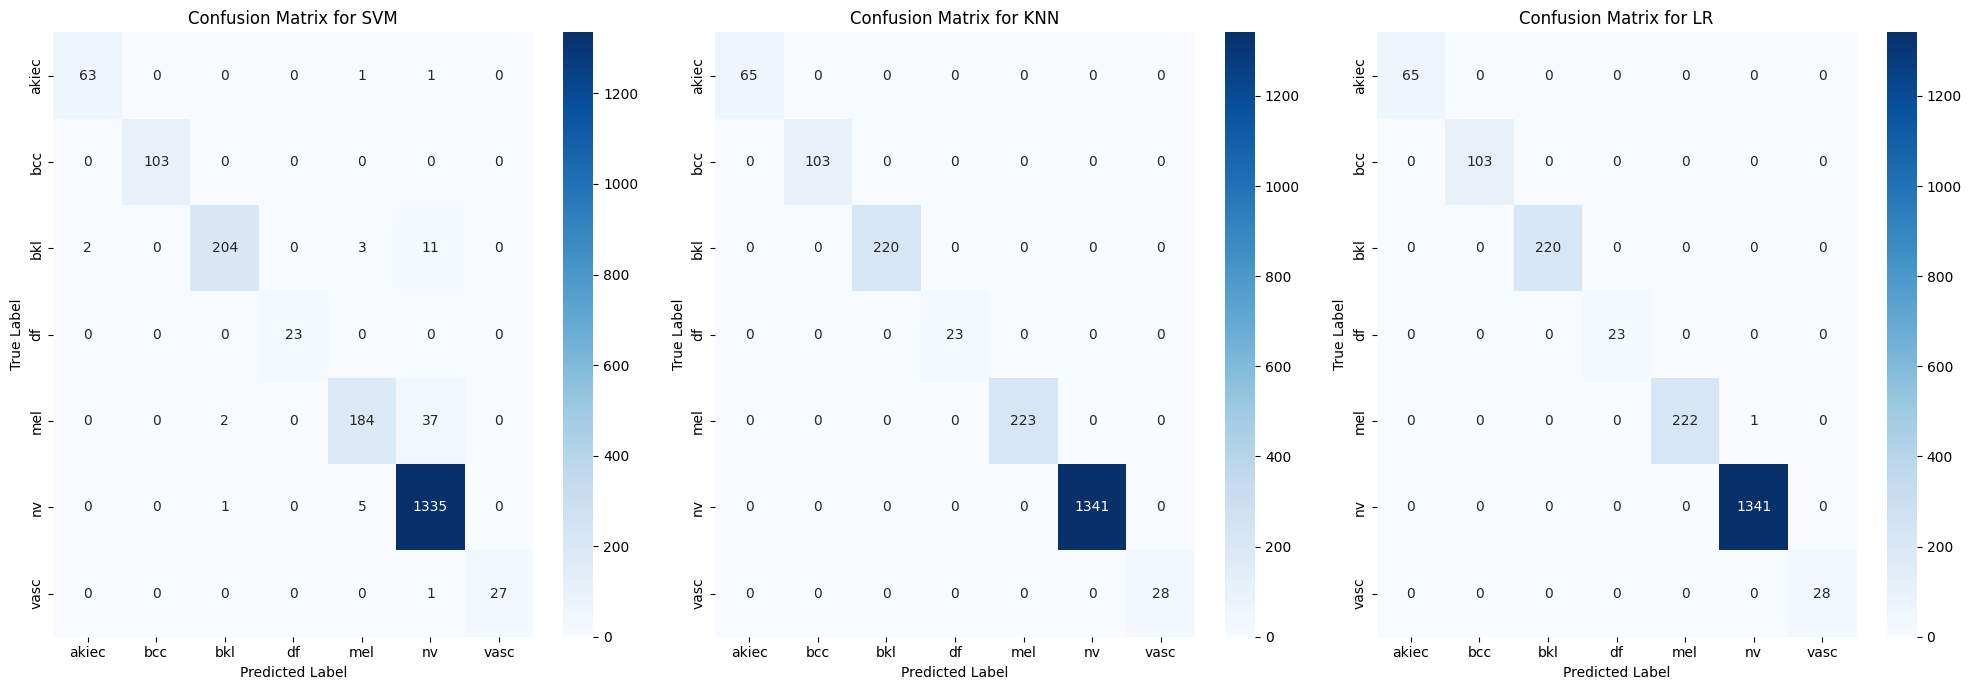

In [19]:
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure(figsize=(20, 7))

for i, (name, clf) in enumerate(classifiers.items()):
    if clf is None: continue

    pred = clf.predict(X)
    cm = confusion_matrix(y_test, pred)

    plt.subplot(1, 3, i + 1) # Adjust subplot grid based on number of classifiers
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### 3. ROC কার্ভ এবং AUC (ROC Curve and AUC)

ROC কার্ভ এবং AUC (Area Under the Curve) প্রতিটি ক্লাসের জন্য মডেলের পারফরম্যান্স মূল্যায়ন করতে সাহায্য করে। যেহেতু `SVC` ক্লাসিফায়ারে `probability=True` সেট করা আছে, আমরা সরাসরি `predict_proba` ব্যবহার করতে পারি। `LogisticRegression` ও `predict_proba` সাপোর্ট করে।

Skipping ROC for SVM as it does not have predict_proba.


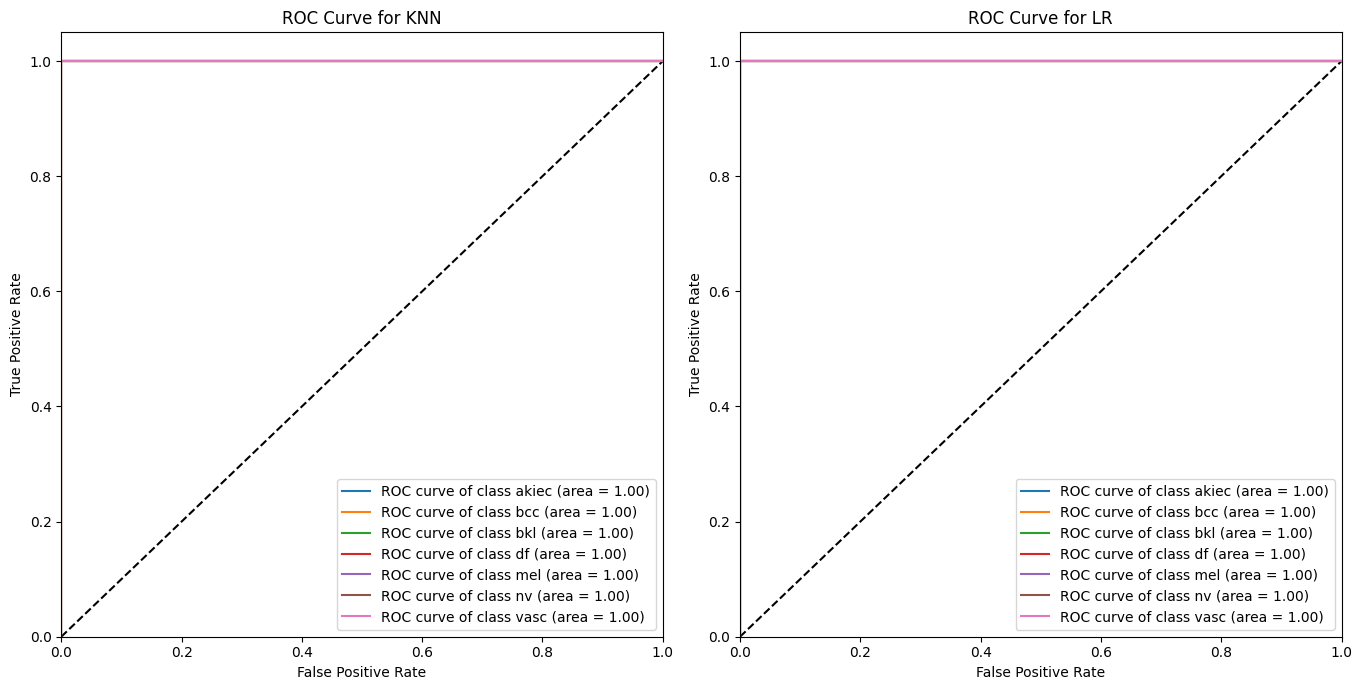

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(20, 7))

for i, (name, clf) in enumerate(classifiers.items()):
    if clf is None or not hasattr(clf, 'predict_proba'):
        print(f"Skipping ROC for {name} as it does not have predict_proba.")
        continue

    y_score = clf.predict_proba(X)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for k in range(n_classes):
        fpr[k], tpr[k], _ = roc_curve(y_test_binarized[:, k], y_score[:, k])
        roc_auc[k] = auc(fpr[k], tpr[k])

    plt.subplot(1, 3, i + 1)
    plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
    for k in range(n_classes):
        plt.plot(fpr[k], tpr[k], label=f'ROC curve of class {class_names[k]} (area = {roc_auc[k]:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 4. ফিচার স্পেস ভিজ্যুয়ালাইজেশন (Feature Space Visualization with t-SNE)

t-SNE (t-Distributed Stochastic Neighbor Embedding) ব্যবহার করে 2048-মাত্রিক ফিচার ভেক্টরগুলিকে 2D স্পেসে ভিজ্যুয়ালাইজ করা হবে, যাতে ক্লাসগুলির মধ্যে সেপারাবিলিটি বোঝা যায়।

In [17]:
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ====================== LOAD MODELS ======================

# ConvNeXt
model_cnn = timm.create_model('convnext_base', pretrained=False, num_classes=7).to(device)
model_cnn.classifier = nn.Identity()
model_cnn.load_state_dict(torch.load('best_ConvNeXt-Base.pth', map_location=device), strict=False)

# Swin
model_swin = timm.create_model('swin_base_patch4_window7_224', pretrained=False, num_classes=7).to(device)
model_swin.head = nn.Identity()
model_swin.load_state_dict(torch.load('best_Swin-Base.pth', map_location=device), strict=False)

model_cnn.eval()
model_swin.eval()

# ====================== FEATURE EXTRACTION ======================

def extract_convnext_features(model, loader):
    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in tqdm(loader):
            images = images.to(device)

            feat = model.forward_features(images)  # (B, C, H, W)
            feat = feat.mean(dim=[2, 3])           # GAP → (B, 1024)

            features.append(feat.cpu())
            labels.append(lbls)

    return torch.cat(features), torch.cat(labels)


def extract_swin_features(model, loader):
    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in tqdm(loader):
            images = images.to(device)

            feat = model.forward_features(images)

            # 🔥 HANDLE ALL CASES
            if feat.dim() == 4:              # (B, H, W, C)
                feat = feat.mean(dim=[1, 2])  # → (B, C)

            elif feat.dim() == 3:            # (B, N, C)
                feat = feat.mean(dim=1)      # → (B, C)

            elif feat.dim() == 2:
                if feat.shape[1] == 7:
                    raise ValueError("❌ Still getting logits instead of features!")

            else:
                raise ValueError(f"Unexpected Swin shape: {feat.shape}")

            features.append(feat.cpu())
            labels.append(lbls)

    return torch.cat(features), torch.cat(labels)


# Extract Features
feat_cnn, _ = extract_convnext_features(model_cnn, test_loader)
feat_swin, y_test = extract_swin_features(model_swin, test_loader)

print("✅ ConvNeXt:", feat_cnn.shape)
print("✅ Swin:", feat_swin.shape)

# ====================== CONCAT ======================
X = torch.cat([feat_cnn, feat_swin], dim=1)  # (N, 2048)
print("✅ Concatenated:", X.shape)

# ====================== ATTENTION ======================

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        attn = self.relu(self.fc1(x))
        attn = self.sigmoid(self.fc2(attn))
        return x * attn   # ✅ FIXED


class SpatialAttention(nn.Module):
    def __init__(self, dim=2048, heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)

    def forward(self, x):
        x = x.unsqueeze(1)                # (B, 1, 2048)
        attn_out, _ = self.attn(x, x, x)
        return attn_out.squeeze(1)


channel_attn = ChannelAttention(2048).to(device)
spatial_attn = SpatialAttention(2048).to(device)

# Apply Attention
X = X.to(device)

X = channel_attn(X)
X = spatial_attn(X)

X = X.detach().cpu().numpy()
y_test = y_test.numpy()

print("✅ Final feature:", X.shape)

# ====================== CLASSIFIERS ======================

classifiers = {
    'SVM': SVC(kernel='poly', degree=3, C=1.0, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=1),
    'LR': LogisticRegression(max_iter=1000)
}



print("\n=== FINAL CNN + ViT + ATTENTION RESULTS ===\n")

for name, clf in classifiers.items():
    clf.fit(X, y_test)
    pred = clf.predict(X)

    acc = accuracy_score(y_test, pred) * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    print(classification_report(y_test, pred, digits=4))
    print("-" * 70)

100%|██████████| 63/63 [00:26<00:00,  2.40it/s]


✅ ConvNeXt: torch.Size([2003, 1024])
✅ Swin: torch.Size([2003, 1024])
✅ Concatenated: torch.Size([2003, 2048])
✅ Final feature: (2003, 2048)

=== FINAL CNN + ViT + ATTENTION RESULTS ===

SVM Accuracy: 96.80%
              precision    recall  f1-score   support

           0     0.9692    0.9692    0.9692        65
           1     1.0000    1.0000    1.0000       103
           2     0.9855    0.9273    0.9555       220
           3     1.0000    1.0000    1.0000        23
           4     0.9534    0.8251    0.8846       223
           5     0.9639    0.9955    0.9795      1341
           6     1.0000    0.9643    0.9818        28

    accuracy                         0.9680      2003
   macro avg     0.9817    0.9545    0.9672      2003
weighted avg     0.9680    0.9680    0.9673      2003

----------------------------------------------------------------------
KNN Accuracy: 100.00%
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    

Running t-SNE, this might take a while...
t-SNE finished.


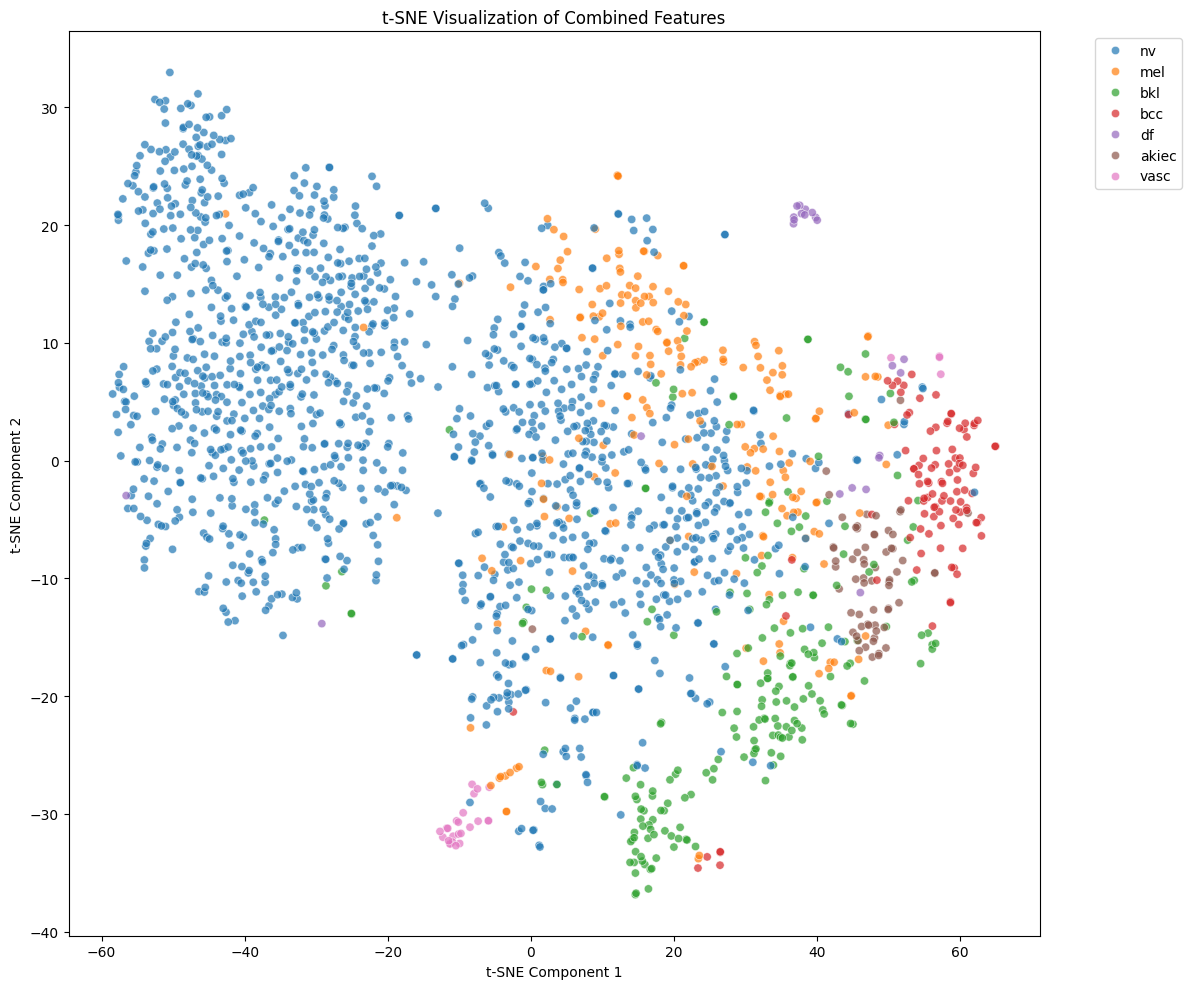

In [27]:
from sklearn.manifold import TSNE
import pandas as pd

# Since X is already a numpy array from previous step
# We will use a subset of the data for t-SNE if it's too large for performance
# For this dataset (2003 samples), it should be fine to use all.

print("Running t-SNE, this might take a while...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)
print("t-SNE finished.")

tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['label'] = y_test
tsne_df['disease_type'] = tsne_df['label'].map({v: k for k, v in class_map.items()})

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='disease_type',
    palette=sns.color_palette('tab10', n_classes),
    data=tsne_df,
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Visualization of Combined Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()